In [10]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
from cleanfid import fid
from metrics.cmmd_pytorch.main import compute_cmmd

import os
import shutil
import glob
import torch
import numpy as np
import datetime
from natsort import natsorted
from IPython.display import clear_output

device = 'cuda:1'
torch.cuda.set_device(device)
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))


/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/nessessence/anaconda3/envs/mace/lib/py

Current device: 1
Device name: NVIDIA GeForce RTX 3090


In [ ]:
import datetime

def get_file_creation_date(filepath):
    timestamp = os.path.getctime(filepath)
    dt = datetime.datetime.fromtimestamp(timestamp)
    return dt.strftime("%d-%m-%y_%H:%M")

def calc_cdist_part(features_1, features_2, batch_size=10000):
    dists = []
    for feat2_batch in features_2.split(batch_size):
        dists.append(torch.cdist(features_1, feat2_batch).cpu())
    return torch.cat(dists, dim=1)


def calculate_precision_recall_part(features_1, features_2, neighborhood=3, batch_size=10000):
    # Precision
    dist_nn_1 = []
    for feat_1_batch in features_1.split(batch_size):
        dist_nn_1.append(calc_cdist_part(feat_1_batch, features_1, batch_size).kthvalue(neighborhood + 1).values)
    dist_nn_1 = torch.cat(dist_nn_1)
    precision = []
    for feat_2_batch in features_2.split(batch_size):
        dist_2_1_batch = calc_cdist_part(feat_2_batch, features_1, batch_size)
        precision.append((dist_2_1_batch <= dist_nn_1).any(dim=1).float())
    precision = torch.cat(precision).mean().item()
    # Recall
    dist_nn_2 = []
    for feat_2_batch in features_2.split(batch_size):
        dist_nn_2.append(calc_cdist_part(feat_2_batch, features_2, batch_size).kthvalue(neighborhood + 1).values)
    dist_nn_2 = torch.cat(dist_nn_2)
    recall = []
    for feat_1_batch in features_1.split(batch_size):
        dist_1_2_batch = calc_cdist_part(feat_1_batch, features_2, batch_size)
        recall.append((dist_1_2_batch <= dist_nn_2).any(dim=1).float())
    recall = torch.cat(recall).mean().item()
    return precision, recall


def get_features(base_dir, use_precompute_features_if_exist=False,max_count=-1):
    # TODO: right now, expect the features to be already exist only
    image_extensions = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.webp")
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(base_dir, ext)))

    if not image_files:
        raise FileNotFoundError(f"No image files found in {base_dir}")

    first_image_path = natsorted(image_files)[0]
    date_str = get_file_creation_date(first_image_path)
        
    if use_precompute_features_if_exist:
        feature_dir = os.path.join(base_dir, "precomputed_features", "clip-l-14")
        # feature_dir = os.path.join(base_dir, "precomputed_features", "clip-b-32")
        feature_filename = f"{date_str}_n{max_count}.npy"
        feature_path = os.path.join(feature_dir, feature_filename)
        
        if os.path.exists(feature_path):
            print(f"Loading precomputed features from {feature_path}")
            feature = np.load(feature_path).astype("float32")
            feature = torch.tensor(feature)
            return feature
        else: print(f'{feature_path} does not exist')
            

def compute_pr(ref_path, eval_path, k=3, use_precompute_features_if_exist=False, feature=None, max_count=None):
    ref_features = get_features(ref_path,use_precompute_features_if_exist=use_precompute_features_if_exist)
    eval_features = get_features(eval_path,use_precompute_features_if_exist=use_precompute_features_if_exist,max_count=max_count)
    precision,recall = calculate_precision_recall_part(ref_features,eval_features)
    
    return (precision,recall)


In [23]:

def plot_multiple_score_curves(steps, all_scores, labels=None, title="Score vs Training Steps", save_path=None, method='KID'):
    plt.figure(figsize=(8, 5))
    for idx, scores in enumerate(all_scores):
        label = labels[idx] if labels else f"Exp {idx+1}"
        plt.plot(steps, scores, marker='o', linestyle='-', label=label)
    plt.xlabel("Training Step")
    plt.ylabel(f"{method.upper()} Score")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# obsolete
def create_limited_folder(original_path, limit, dummy_path):
    os.makedirs(dummy_path, exist_ok=True)
    image_extensions = ('*.png', '*.jpg', '*.jpeg', '*.webp', '*.bmp')
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(original_path, ext)))
    image_files = sorted(image_files)[:limit]
    for img_file in image_files:
        if os.path.isfile(img_file):
            shutil.copy(img_file, dummy_path)

def flatten_path(path):
    return os.path.normpath(path).replace(os.sep, '__')

def get_first_image_creation_date(folder):
    image_files = []
    for ext in ('*.png', '*.jpg', '*.jpeg', '*.webp', '*.bmp'):
        image_files.extend(glob.glob(os.path.join(folder, ext)))
    if not image_files:
        raise FileNotFoundError(f"No images found in {folder}")
    first_img = natsorted(image_files)[0]
    ts = os.path.getctime(first_img)
    return datetime.datetime.fromtimestamp(ts).strftime("%d-%m-%y_%H:%M")

def build_score_cache_path(method, eval_path, ref_path, n_max_gen_img):
    f_eval = flatten_path(eval_path)
    f_ref  = flatten_path(ref_path)
    t_eval = get_first_image_creation_date(eval_path)
    t_ref  = get_first_image_creation_date(ref_path)
    filename = f"{f_eval}:{t_eval}--{f_ref}:{t_ref}_n{n_max_gen_img}.npy"
    return os.path.join("data_root", "cache", "precomputed_scores", method, filename)

def compute_distribution_score_multiexp(
    gen_img_paths,
    ref_img_path,
    steps,
    labels=None,
    device='cuda',
    n_max_gen_img=None,
    method='kid',
    use_precompute_features_if_exist=False,
    use_precompute_score_if_exist=False,
):
    if labels and len(labels) != len(gen_img_paths):
        raise ValueError("The number of labels must match the number of generated image paths.")

    all_scores = []

    for gen_path in gen_img_paths:
        scores = []
        for step in steps:
            path_for_eval = gen_path.format(step) if "{}" in gen_path else gen_path
            
            cache_path = build_score_cache_path(method, path_for_eval, ref_img_path, n_max_gen_img)
            if use_precompute_score_if_exist:
                if os.path.exists(cache_path):
                    score = np.load(cache_path).item()
                    print(f"[CACHED] {method.upper()} from {cache_path}")
                else:
                    score = _compute(method, ref_img_path, path_for_eval, device, n_max_gen_img, use_precompute_features_if_exist)
                    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
                    np.save(cache_path, score)
                    print(f"[SAVED] {method.upper()} to {cache_path}")
            else:
                score = _compute(method, ref_img_path, path_for_eval, device, n_max_gen_img, use_precompute_features_if_exist)
                os.makedirs(os.path.dirname(cache_path), exist_ok=True)
                np.save(cache_path, score)
                print(f"[SAVED] {method.upper()} to {cache_path}")
                
            if "{}" not in gen_path:
                print(f'{gen_path} | {method.upper()}: {score}')
                scores = [score] * len(steps)
                break
            else:
                print(f'{gen_path} | Step {step} - {method.upper()}: {score}')
                scores.append(score)

        all_scores.append(scores)

    clear_output(wait=True)
    if method == 'pr':
        Precisions = [[p for p, _ in sublist] for sublist in all_scores]
        Recalls = [[r for _, r in sublist] for sublist in all_scores]
        plot_multiple_score_curves(steps, Precisions, labels, method='precision')
        plot_multiple_score_curves(steps, Recalls, labels, method='recall')
    else:
        
        plot_multiple_score_curves(steps, all_scores, labels, method=method)
    return all_scores

def _compute(method, ref_path, eval_path, device, n_max_gen_img, use_precompute_features_if_exist):
    if method == 'kid':
        return fid.compute_kid(eval_path, ref_path, n_max_gen_img=n_max_gen_img, device=device, use_dataparallel=False)
    elif method == 'cmmd':
        return compute_cmmd(
            ref_path,
            eval_path,
            batch_size=10,
            max_count=-1 if n_max_gen_img is None else n_max_gen_img,
            use_precompute_features_if_exist=use_precompute_features_if_exist
        ).item()
    elif method == 'pr':
        return compute_pr(ref_path, eval_path, k=5, use_precompute_features_if_exist=use_precompute_features_if_exist)
    else:
        raise ValueError(f"Unsupported method: {method}")

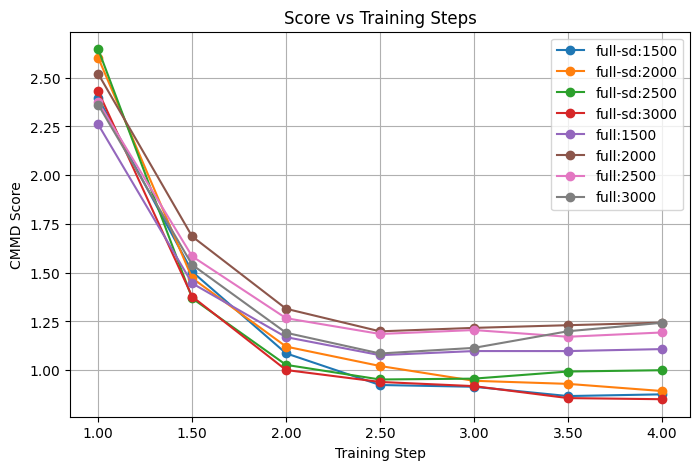

In [13]:

gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/sd/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(1500,3500,500)]  + [f"full:{step}" for step in range(1500,3500,500)] 

# labels = [f"full-sd:{step}" for step in range(2000,3500,500)] + [f"full-sd.cbh:{step}" for step in range(2000,2500,500)]  + [f"full:{step}" for step in range(2000,3500,500)] + [f"full.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)

In [24]:

gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/sd/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(1500,3500,500)]  + [f"full:{step}" for step in range(1500,3500,500)] 

# labels = [f"full-sd:{step}" for step in range(2000,3500,500)] + [f"full-sd.cbh:{step}" for step in range(2000,2500,500)]  + [f"full:{step}" for step in range(2000,3500,500)] + [f"full.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='pr',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)

data_root/data/real_data/crybaby/sd/crybaby-50/precomputed_features/clip-l-14/25-05-25_12:36_n-1.npy does not exist
data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/1.00/precomputed_features/clip-l-14/03-06-25_06:47_nNone.npy does not exist


AttributeError: 'NoneType' object has no attribute 'split'

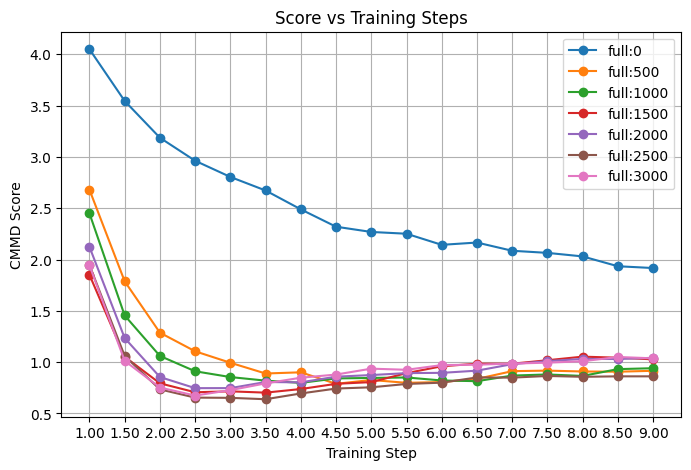

In [20]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-0/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = [f"full:{s}" for s in range(0,3500,500)]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


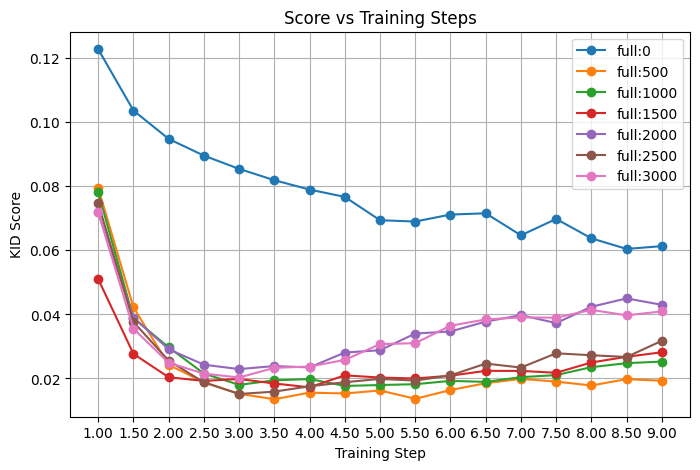

In [21]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-0/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = [f"full:{s}" for s in range(0,3500,500)]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


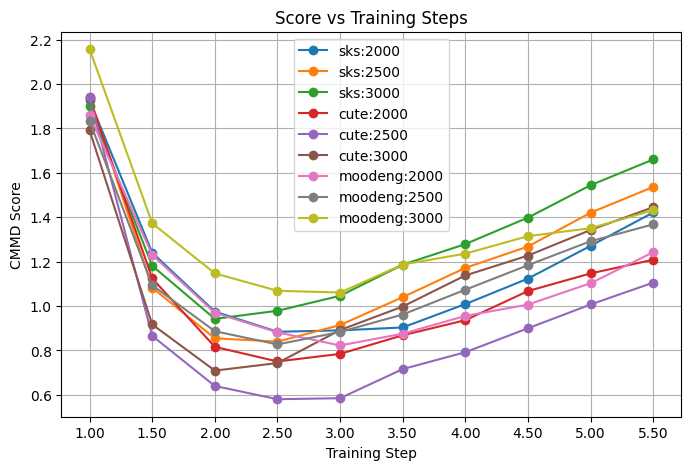

In [12]:

gen_img_paths = [
    
    "data_root/generated/model/c.l4.kv_moodeng-50.sks_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of sks hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.sks_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of sks hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.sks_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of sks hippo/{}",

    
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
    
    
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/sd/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 6.0, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"sks:{s}" for s in range(2000,3500,500)] + [f"cute:{s}" for s in range(2000,3500,500)] +  [f"moodeng:{s}" for s in range(2000,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


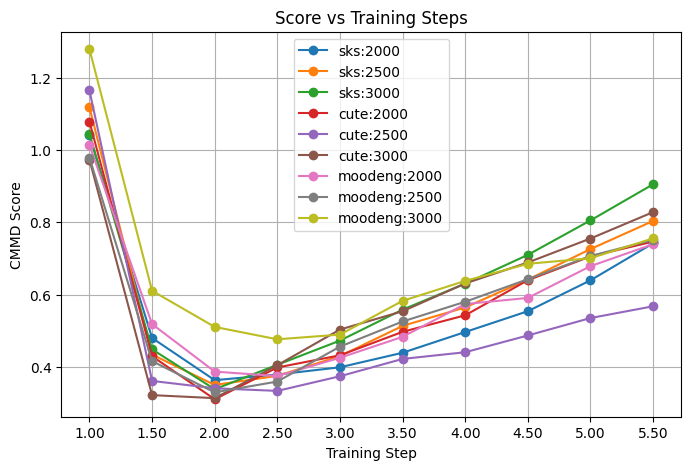

In [11]:

gen_img_paths = [
    
    "data_root/generated/model/c.l4.kv_moodeng-50.sks_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of sks hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.sks_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of sks hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.sks_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of sks hippo/{}",

    
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
    
    
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 6.0, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"sks:{s}" for s in range(2000,3500,500)] + [f"cute:{s}" for s in range(2000,3500,500)] +  [f"moodeng:{s}" for s in range(2000,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


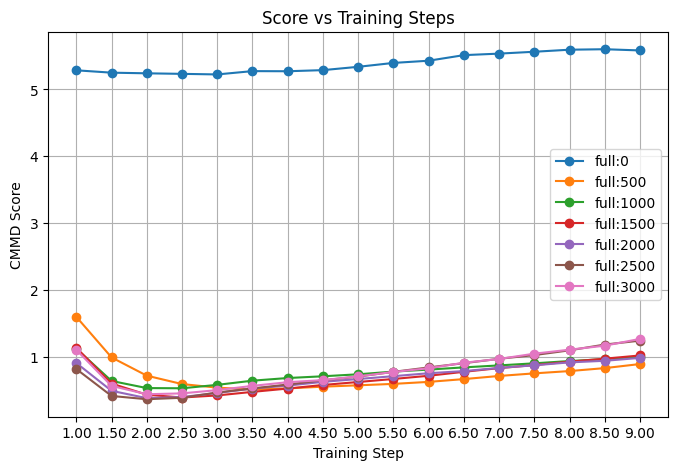

In [ ]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a hippo/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-0/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"full:{s}" for s in range(0,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=300, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


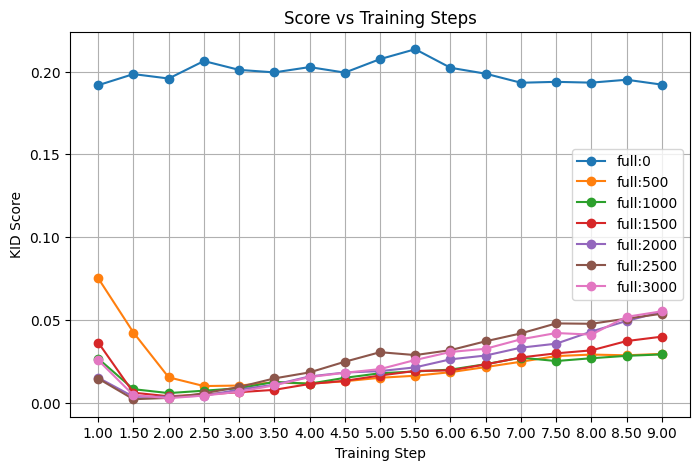

In [22]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a hippo/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-0/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"full:{s}" for s in range(0,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


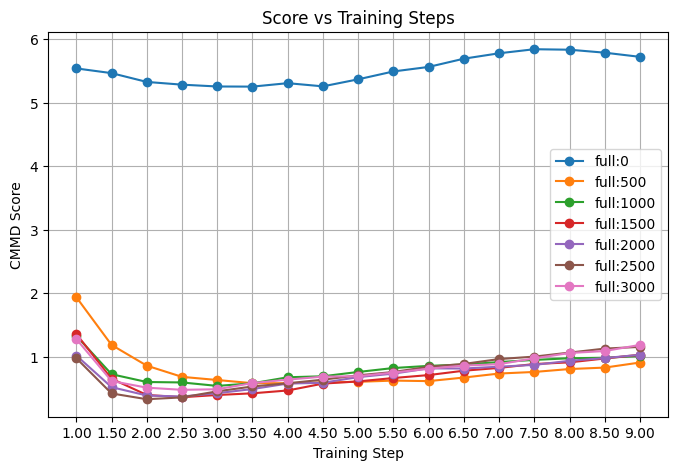

In [23]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a hippo/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-0/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"full:{s}" for s in range(0,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


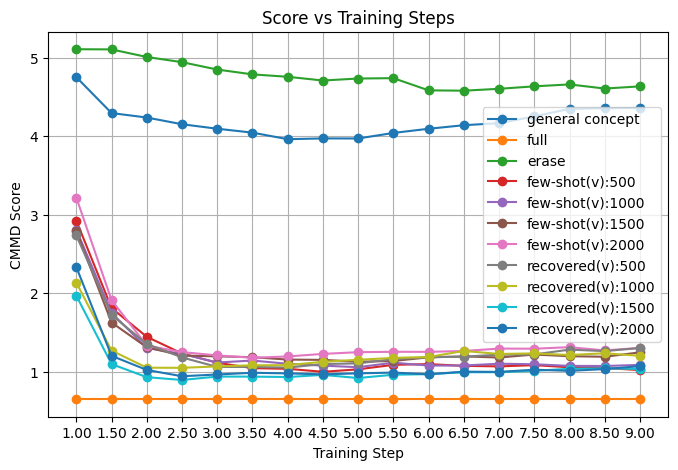

In [13]:

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


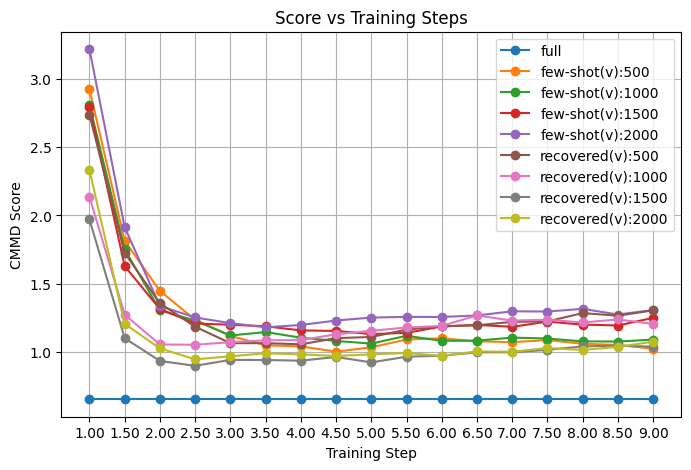

In [14]:

gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


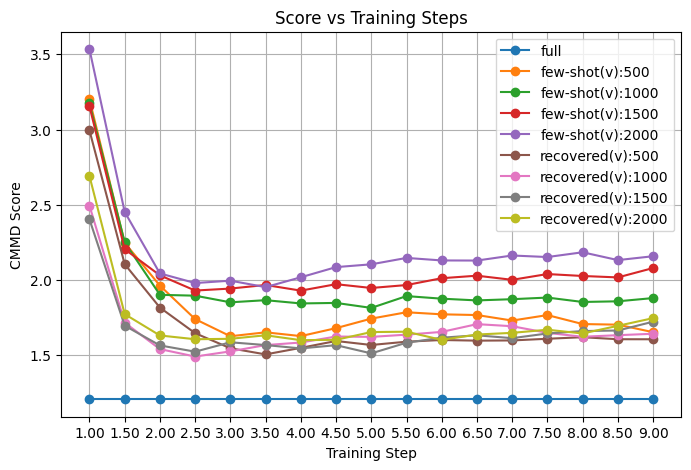

Error during conversion: ChunkedEncodingError(ProtocolError('Response ended prematurely'))


In [16]:
# sd
gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/sd/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


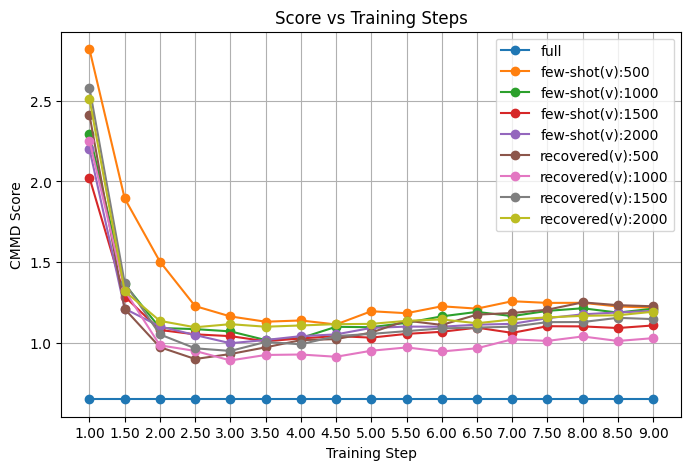

In [15]:

gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


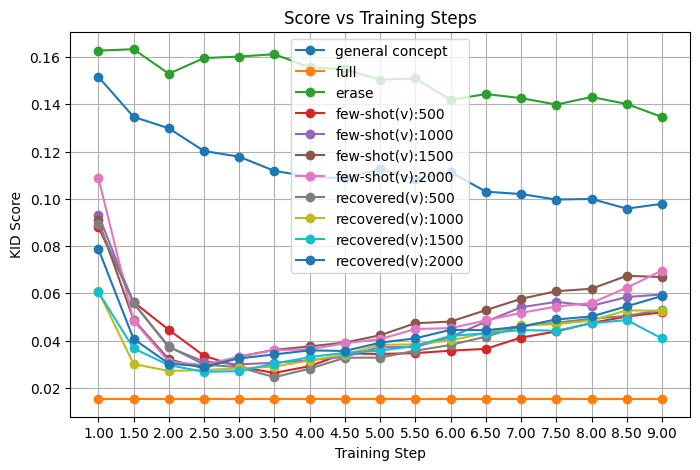

In [6]:

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


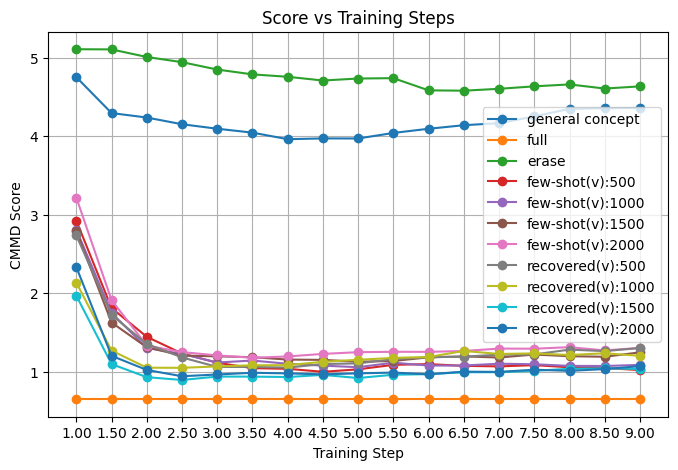

In [7]:

# TODO: Test
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


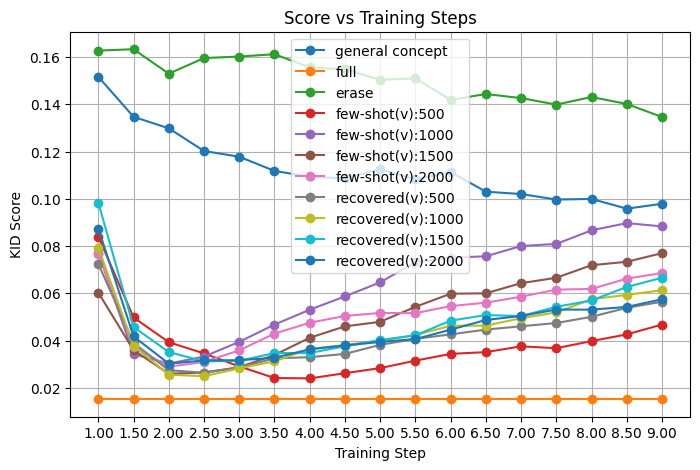

In [8]:

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
# labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


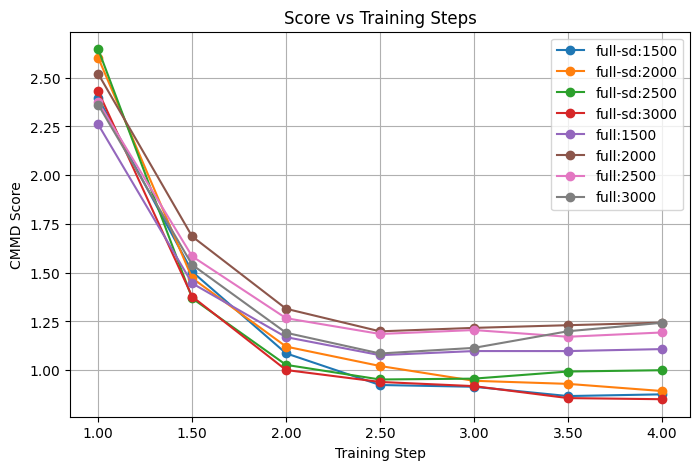

In [5]:

gen_img_paths = [
    

        
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/sd/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(1500,3500,500)]  + [f"full:{step}" for step in range(1500,3500,500)] 

# labels = [f"full-sd:{step}" for step in range(2000,3500,500)] + [f"full-sd.cbh:{step}" for step in range(2000,2500,500)]  + [f"full:{step}" for step in range(2000,3500,500)] + [f"full.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)

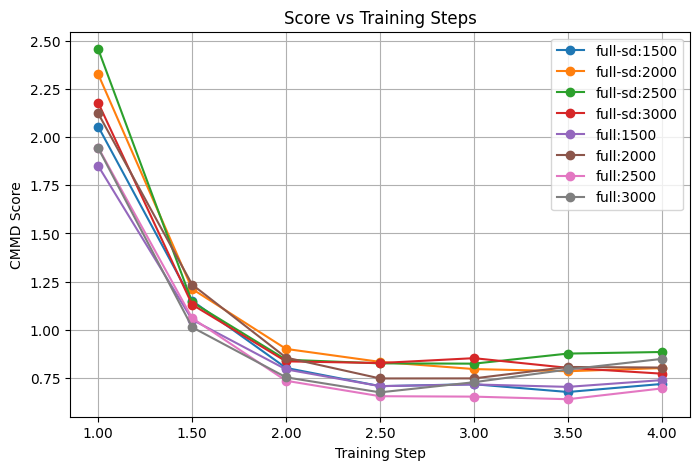

In [6]:

gen_img_paths = [
    

        
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(1500,3500,500)]  + [f"full:{step}" for step in range(1500,3500,500)] 

# labels = [f"full-sd:{step}" for step in range(2000,3500,500)] + [f"full-sd.cbh:{step}" for step in range(2000,2500,500)]  + [f"full:{step}" for step in range(2000,3500,500)] + [f"full.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)

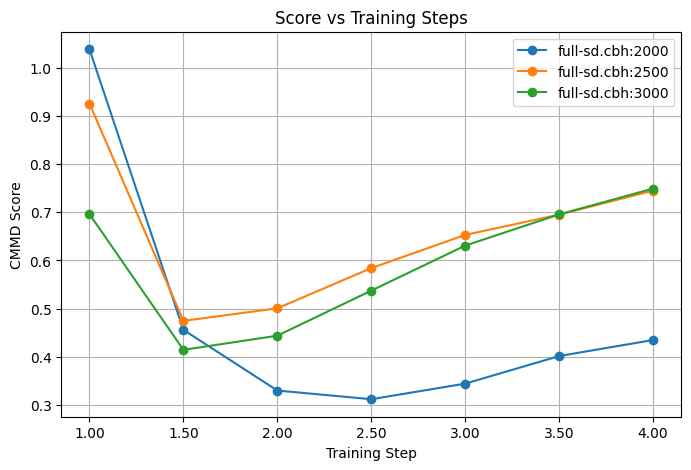

In [ ]:

# CLIP-B-32
gen_img_paths = [
    

    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
    
]
ref_img_path = "data_root/data/real_data/moodeng/sd/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=False)

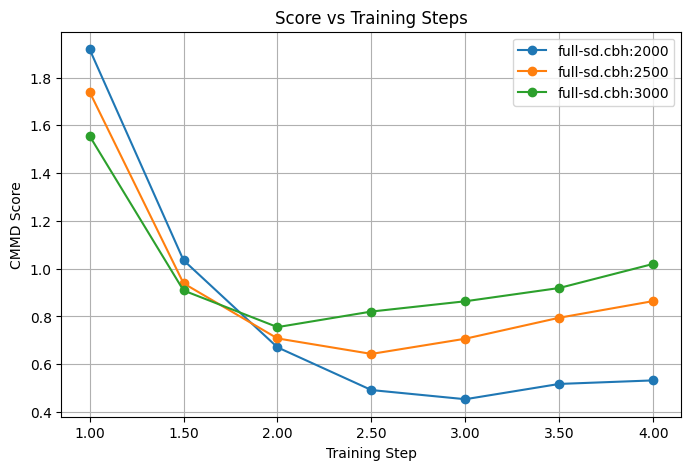

In [3]:

# CLIP-L-14
gen_img_paths = [
    

    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
    
]
ref_img_path = "data_root/data/real_data/moodeng/sd/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)

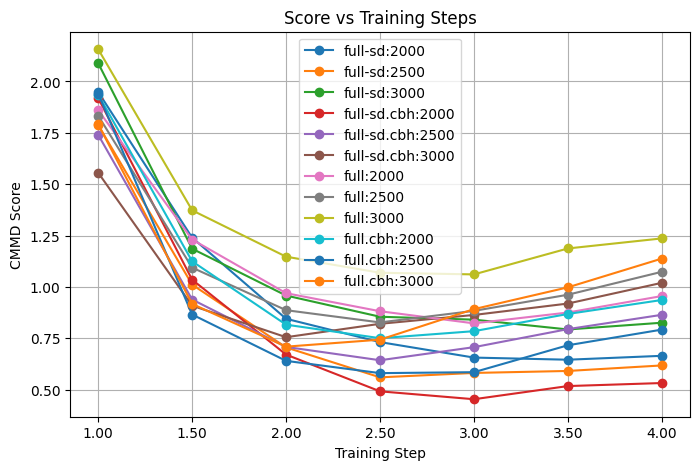

In [33]:

gen_img_paths = [
    

    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
        
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
    

    
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    
        "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/sd/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(2000,3500,500)] + [f"full-sd.cbh:{step}" for step in range(2000,3500,500)]  + [f"full:{step}" for step in range(2000,3500,500)] + [f"full.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


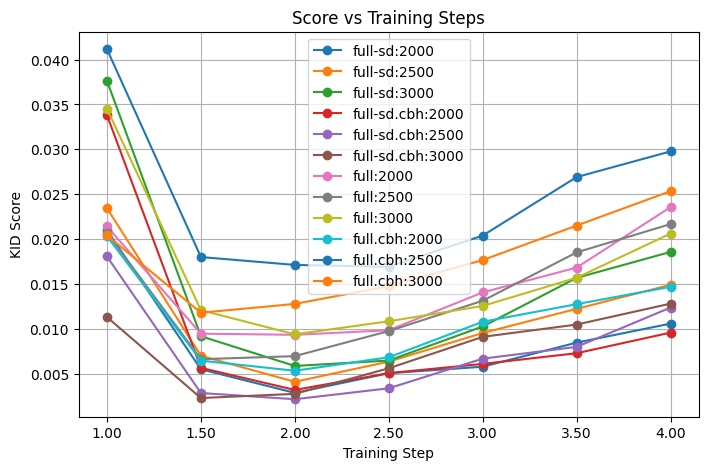

In [34]:
gen_img_paths = [
    

    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
        
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
    

    
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    
        "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a cute baby hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50.cbh_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a cute baby hippo/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/sd/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 4.5, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(2000,3500,500)] + [f"full-sd.cbh:{step}" for step in range(2000,3500,500)]  + [f"full:{step}" for step in range(2000,3500,500)] + [f"full.cbh:{step}" for step in range(2000,3500,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)

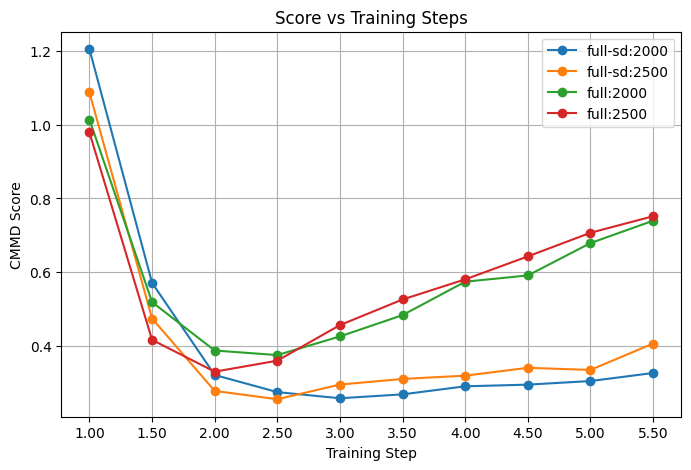

In [24]:

gen_img_paths = [
    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-sd-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",

]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 6.0, 0.5).tolist()]
labels = [f"full-sd:{step}" for step in range(2000,3000,500)] + [f"full:{step}" for step in range(2000,3000,500)]
all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


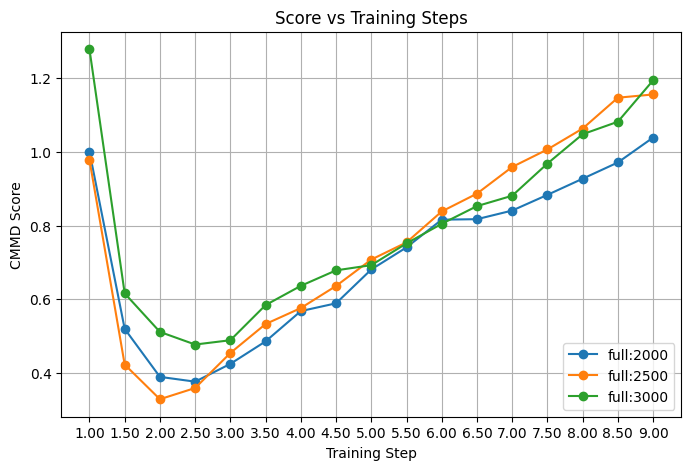

In [52]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a hippo/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"full:{step}" for step in range(2000,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


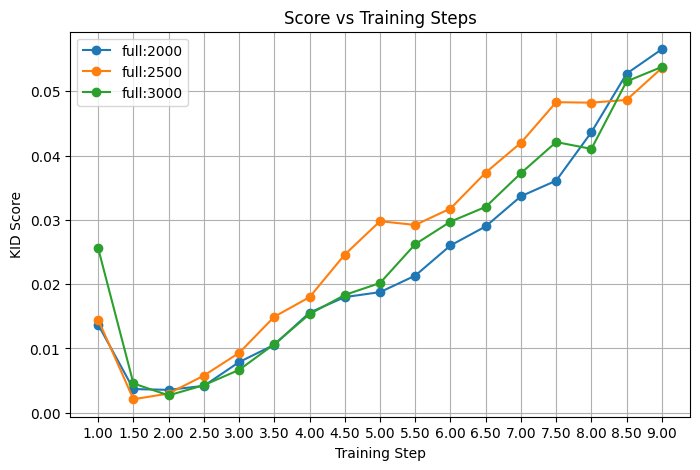

In [53]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a hippo/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-500/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1000/A photo of moodeng/{}",
    # "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-1500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
# labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = [f"full:{step}" for step in range(2000,3500,500)]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


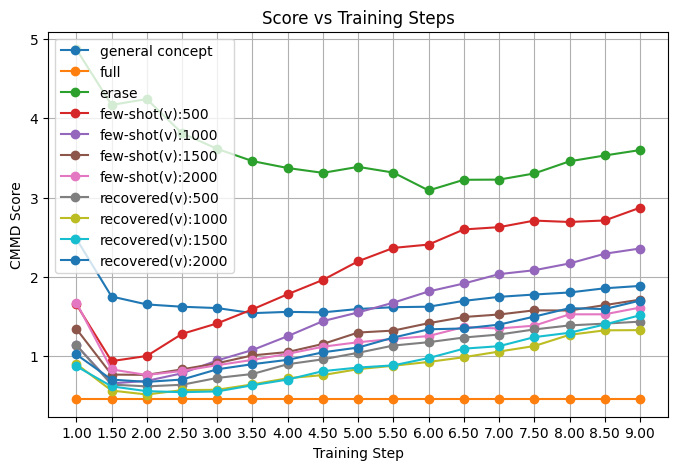

In [47]:

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


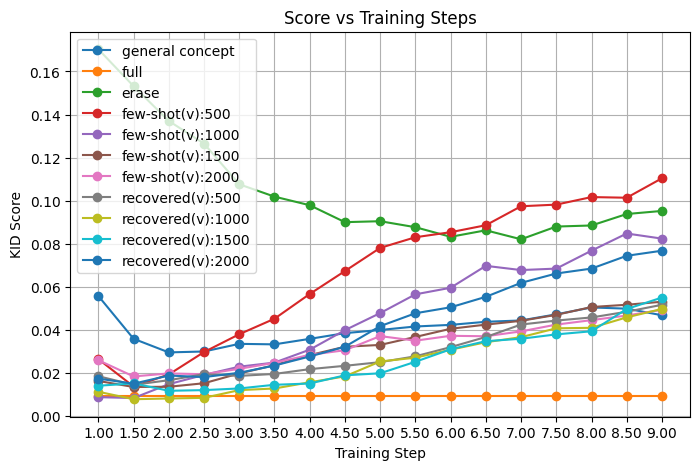

In [48]:

# test
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


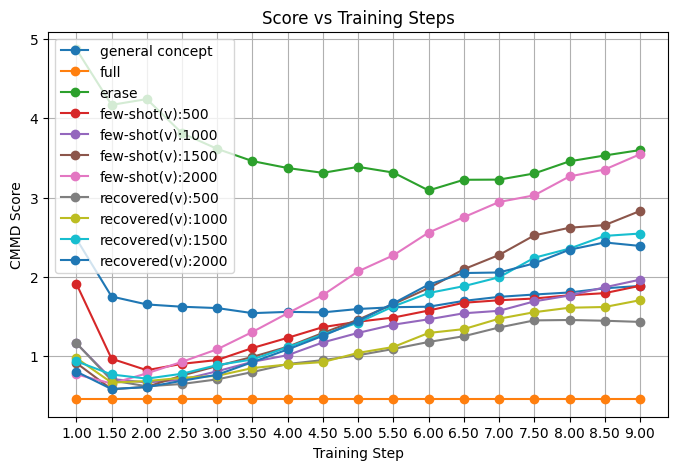

In [49]:

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


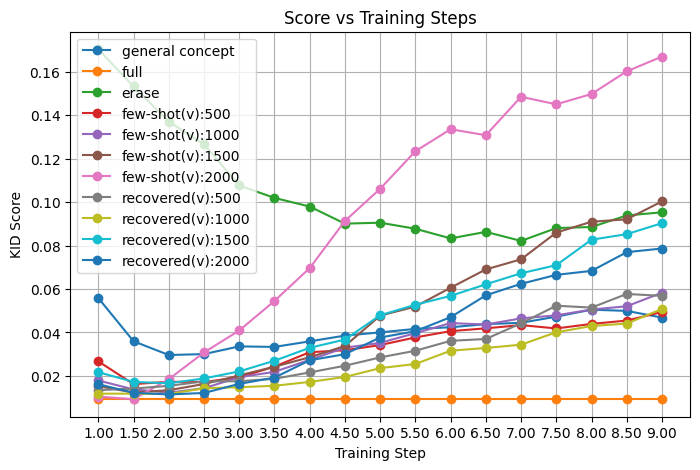

In [50]:

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):500", "few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):500", "recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


[CACHED] CMMD from data_root/cache/precomputed_scores/cmmd/data_root__generated__model__c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4__checkpoint-2500__A photo of a crybaby art toy__3.00:28-05-25_13:55--data_root__data__real_data__crybaby__crybaby-50:25-05-25_12:36_n50.npy
data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00 | CMMD: 0.6549358367919922
[CACHED] CMMD from data_root/cache/precomputed_scores/cmmd/data_root__generated__model__c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4__checkpoint-1000__A photo of a v1__1.00:29-05-25_19:09--data_root__data__real_data__crybaby__crybaby-50:25-05-25_12:36_n50.npy
data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{} | Step 1.00 - CMMD: 2.8128623962402344
[CACHED] CMMD from data_root/cache/precomputed_scores/cmmd/data_root__generated__model__c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4__checkpoint-1000__A photo of a v1__1.50:29-05-25_19:

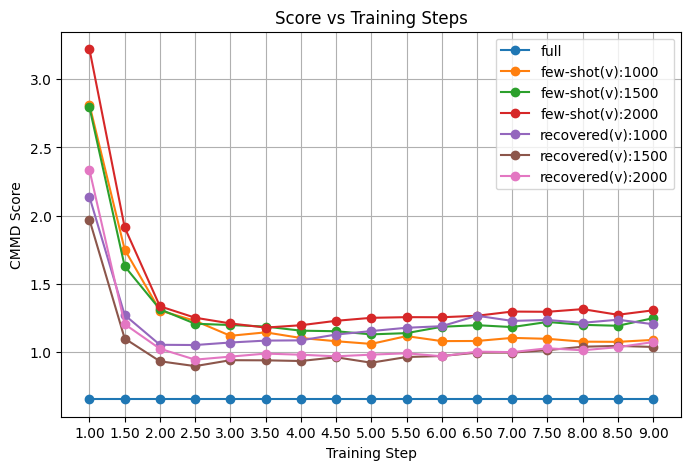

In [14]:

gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/{}",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erase","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]
labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

all_scores = compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


Loading precomputed features from data_root/data/real_data/crybaby/crybaby-50/precomputed_features/clip-l-14/25-05-25_12:36_n50.npy
Loading precomputed features from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00/precomputed_features/clip-l-14/28-05-25_13:55_n50.npy
data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00 | CMMD score: 0.6549358367919922
Loading precomputed features from data_root/data/real_data/crybaby/crybaby-50/precomputed_features/clip-l-14/25-05-25_12:36_n50.npy
Loading precomputed features from data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/1.00/precomputed_features/clip-l-14/29-05-25_19:09_n50.npy
data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{} | Step 1.00 - CMMD score: 2.8128623962402344
Loading precomputed features from data

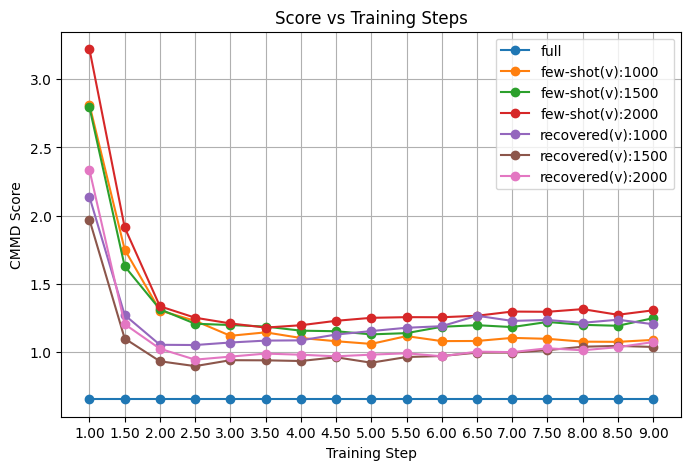

[[0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922],
 [2.8128623962402344,
  1.751542091369629,
  1.3049840927124023,
  1.229405403137207,
  1.1197328567504883,
  1.1448860168457031,
  1.1037588119506836,
  1.0799169540405273,
  1.0602474212646484,
  1.1173486709594727,
  1.0807514190673828,
  1.081705093383789,
  1.1043548583984375,
  1.097559928894043,
  1.076817512512207,
  1.0753870010375977,
  1.0895729064941406],
 [2.7937889099121094,
  1.628875732421875,
  1.3138055801391602,
  1.2080669403076172,
  1.1986494064331055,
  1.187443733215332,
  1.1572837829589844,
  1.153111457824707,
  1.1301040649414062,
  1.1391639709472656,
  1.185774803161621,
  1.1974573135375

In [6]:

# test
gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/7.50",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True)


Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.39it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.34it/s]


data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00 | CMMD score: 0.6549358367919922
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 8.50 - CMMD score: 1.0364055633544922
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.36it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/9.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 9.00 - CMMD score: 1.0737180709838867


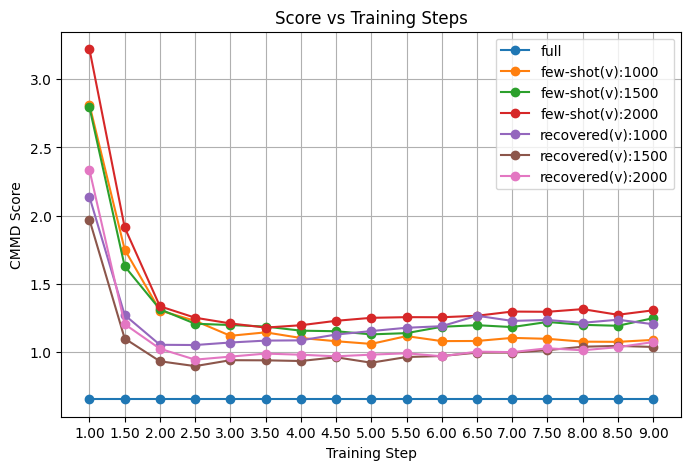

[[0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922,
  0.6549358367919922],
 [2.8128623962402344,
  1.751542091369629,
  1.3049840927124023,
  1.229405403137207,
  1.1197328567504883,
  1.1448860168457031,
  1.1037588119506836,
  1.0799169540405273,
  1.0602474212646484,
  1.1173486709594727,
  1.0807514190673828,
  1.081705093383789,
  1.1043548583984375,
  1.097559928894043,
  1.076817512512207,
  1.0753870010375977,
  1.0895729064941406],
 [2.7937889099121094,
  1.628875732421875,
  1.3138055801391602,
  1.2080669403076172,
  1.1986494064331055,
  1.187443733215332,
  1.1572837829589844,
  1.153111457824707,
  1.1301040649414062,
  1.1391639709472656,
  1.185774803161621,
  1.1974573135375

In [ ]:


gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/7.50",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd')

compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00-dummy-50


KID 3.00-dummy-50 : 100%|█████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.97s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.78s/it]


data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00 | KID score: 0.014961227758290573
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/1.00-dummy-50


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 8.50 - KID score: 0.05450539795918364
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/9.00-dummy-50


KID 9.00-dummy-50 : 100%|█████████████████████████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.01s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.87s/it]


data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 9.00 - KID score: 0.05884874238679847


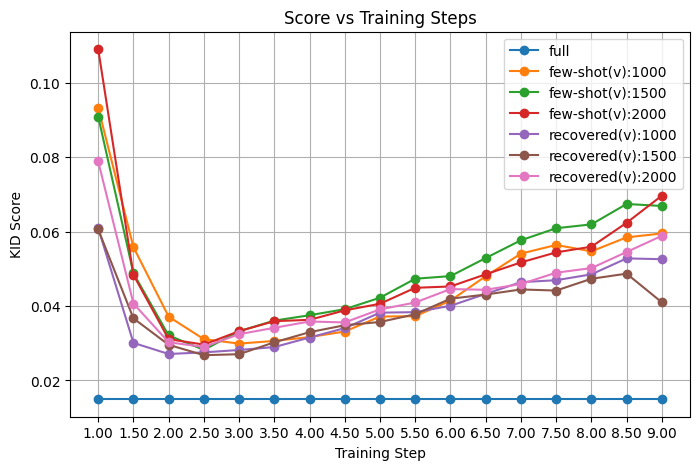

[[0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573,
  0.014961227758290573],
 [0.0932382293925379,
  0.05581765676817583,
  0.03713274828603303,
  0.03108551646205376,
  0.029906421197385333,
  0.030616918327487495,
  0.0316580764508928,
  0.03314901885363517,
  0.03717098214285727,
  0.037264754942601994,
  0.04144544722576529,
  0.04800656138392876,
  0.0540712297512756,
  0.056396888711734545,
  0.05468151430963023,
  0.05843346795280638,
  0.059487467594069046],
 [0.09086485168207903,
  0.0487743971221299,
  0.03209190429687523,
  0.028219503427933956,
  0.033226403977997566,
  0.03607533677455355,
  0.03752034402901786,
  0.039149571747449034,
  0.0422303

In [ ]:


gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/3.00",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/7.50",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid')

Loading precomputed features from data_root/data/real_data/moodeng/moodeng-50/precomputed_features/clip-l-14/25-05-25_12:58_n50.npy
Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo/1.00.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.10it/s]


Saving computed features to data_root/generated/general_concepts/A photo of a hippo/1.00/precomputed_features/clip-l-14/30-05-25_18:06_n50.npy
[SAVED] CMMD to data_root/cache/precomputed_scores/cmmd/data_root__generated__general_concepts__A photo of a hippo__1.00:30-05-25_18:06--data_root__data__real_data__moodeng__moodeng-50:25-05-25_12:58_n50.npy
data_root/generated/general_concepts/A photo of a hippo/{} | Step 1.00 - CMMD: 2.479672431945801
Loading precomputed features from data_root/data/real_data/moodeng/moodeng-50/precomputed_features/clip-l-14/25-05-25_12:58_n50.npy
Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo/1.50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.26it/s]


Saving computed features to data_root/generated/general_concepts/A photo of a hippo/1.50/precomputed_features/clip-l-14/30-05-25_18:07_n50.npy
[SAVED] CMMD to data_root/cache/precomputed_scores/cmmd/data_root__generated__general_concepts__A photo of a hippo__1.50:30-05-25_18:07--data_root__data__real_data__moodeng__moodeng-50:25-05-25_12:58_n50.npy
data_root/generated/general_concepts/A photo of a hippo/{} | Step 1.50 - CMMD: 1.7510652542114258
Loading precomputed features from data_root/data/real_data/moodeng/moodeng-50/precomputed_features/clip-l-14/25-05-25_12:58_n50.npy
Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo/2.00.


...

Saving computed features to data_root/generated/general_concepts/A photo of a hippo/8.00/precomputed_features/clip-l-14/30-05-25_18:41_n50.npy
[SAVED] CMMD to data_root/cache/precomputed_scores/cmmd/data_root__generated__general_concepts__A photo of a hippo__8.00:30-05-25_18:41--data_root__data__real_data__moodeng__moodeng-50:25-05-25_12:58_n50.npy
data_root/generated/general_concepts/A photo of a hippo/{} | Step 8.00 - CMMD: 1.8020868301391602
Loading precomputed features from data_root/data/real_data/moodeng/moodeng-50/precomputed_features/clip-l-14/25-05-25_12:58_n50.npy
Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo/8.50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


Saving computed features to data_root/generated/general_concepts/A photo of a hippo/8.50/precomputed_features/clip-l-14/30-05-25_18:44_n50.npy
[SAVED] CMMD to data_root/cache/precomputed_scores/cmmd/data_root__generated__general_concepts__A photo of a hippo__8.50:30-05-25_18:44--data_root__data__real_data__moodeng__moodeng-50:25-05-25_12:58_n50.npy
data_root/generated/general_concepts/A photo of a hippo/{} | Step 8.50 - CMMD: 1.8547773361206055
Loading precomputed features from data_root/data/real_data/moodeng/moodeng-50/precomputed_features/clip-l-14/25-05-25_12:58_n50.npy
Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo/9.00.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.43it/s]


Saving computed features to data_root/generated/general_concepts/A photo of a hippo/9.00/precomputed_features/clip-l-14/30-05-25_18:46_n50.npy
[SAVED] CMMD to data_root/cache/precomputed_scores/cmmd/data_root__generated__general_concepts__A photo of a hippo__9.00:30-05-25_18:46--data_root__data__real_data__moodeng__moodeng-50:25-05-25_12:58_n50.npy
data_root/generated/general_concepts/A photo of a hippo/{} | Step 9.00 - CMMD: 1.8845796585083008
[CACHED] CMMD from data_root/cache/precomputed_scores/cmmd/data_root__generated__model__c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4__checkpoint-2500__A photo of moodeng__3.00:29-05-25_17:42--data_root__data__real_data__moodeng__moodeng-50:25-05-25_12:58_n50.npy
data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00 | CMMD: 0.45478343963623047
[CACHED] CMMD from data_root/cache/precomputed_scores/cmmd/data_root__generated__model__erase_moodeng.object_lr2.5e-4__A photo of moodeng__1.00:30-05-25_12:24--dat

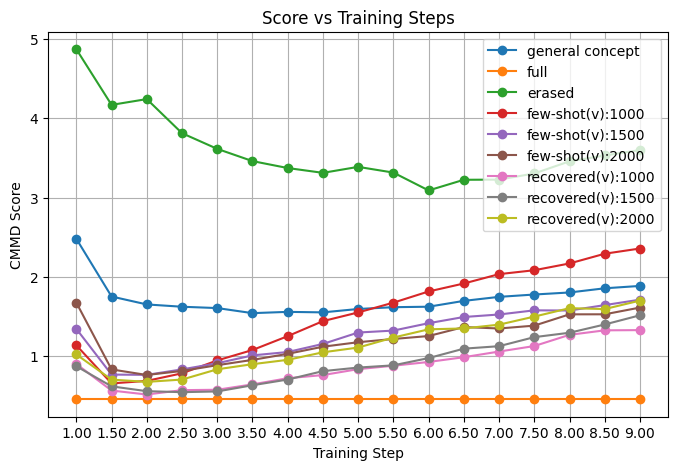

[[2.479672431945801,
  1.7510652542114258,
  1.6510486602783203,
  1.6219615936279297,
  1.6051530838012695,
  1.5411376953125,
  1.5572309494018555,
  1.550912857055664,
  1.5935897827148438,
  1.6162395477294922,
  1.622319221496582,
  1.695871353149414,
  1.7466545104980469,
  1.7762184143066406,
  1.8020868301391602,
  1.8547773361206055,
  1.8845796585083008],
 [0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047],
 [4.87208366394043,
  4.169583320617676,
  4.242658615112305,
  3.8123130798339844,
  3.6144256591796875,
  3.460049629211426,
  3.3725500106811523,
  3.3118724822998047,
  3.3872127532958984,
  3.315091133117676,
  3.089785575866699,
  3.2

In [18]:

# test
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erased","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


In [ ]:

# todo: test
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng/{}",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full","erased","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid',use_precompute_features_if_exist=True,use_precompute_score_if_exist=True)


Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.43it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00 | CMMD score: 0.45478343963623047
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 8.50 - CMMD score: 1.5927553176879883
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/9.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 9.00 - CMMD score: 1.6994476318359375


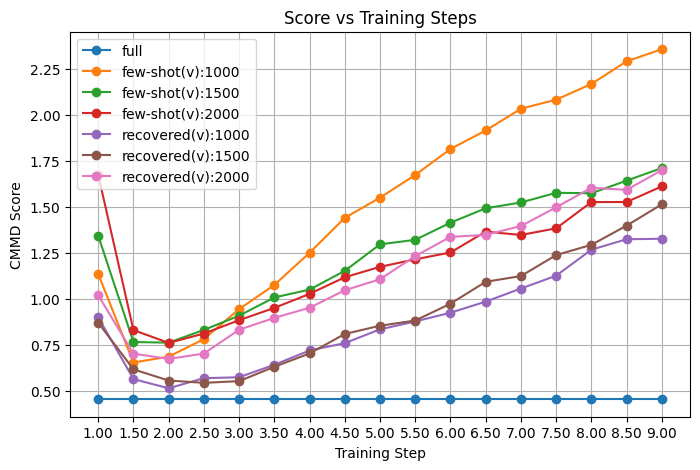

[[0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047,
  0.45478343963623047],
 [1.1354684829711914,
  0.6542205810546875,
  0.6861686706542969,
  0.7817745208740234,
  0.9444952011108398,
  1.07574462890625,
  1.250624656677246,
  1.4405250549316406,
  1.5501976013183594,
  1.673579216003418,
  1.8148422241210938,
  1.9153356552124023,
  2.033352851867676,
  2.08282470703125,
  2.1681785583496094,
  2.291083335876465,
  2.356886863708496],
 [1.3430118560791016,
  0.765681266784668,
  0.7622241973876953,
  0.8313655853271484,
  0.9087324142456055,
  1.0079145431518555,
  1.0504722595214844,
  1.1525154113769531,
  1.296401023864746,
  1.3210773468017578,
  1.4142990112304688,
  

In [ ]:


gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of a moodeng art toy/7.50",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd')

compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00-dummy-50


KID 3.00-dummy-50 : 100%|█████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.97s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.95s/it]


data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00 | KID score: 0.009315565369898355
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/1.00-dummy-50


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 8.50 - KID score: 0.07445432477678597
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/9.00-dummy-50


KID 9.00-dummy-50 : 100%|█████████████████████████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.44s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.48s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 9.00 - KID score: 0.07681329113520413


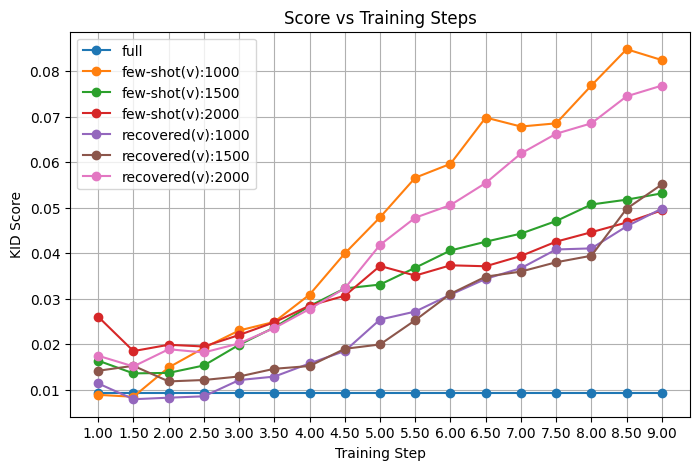

[[0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355,
  0.009315565369898355],
 [0.008859811623087036,
  0.008445070192920871,
  0.014886364038584503,
  0.019187473812181145,
  0.023003866470025298,
  0.024896461176658224,
  0.03088489054528079,
  0.039941177256058606,
  0.04786584960937478,
  0.056572859414859795,
  0.05962326422991041,
  0.06978804392538271,
  0.06781508294802276,
  0.06852226430963011,
  0.07683673421556086,
  0.08480368463010207,
  0.0824195249123088],
 [0.016373134088010107,
  0.013580468590561515,
  0.013687823102678192,
  0.015320173270089226,
  0.01986325928730868,
  0.02367970440051025,
  0.02837415593112247,
  0.03224248186383923,
  0.

In [ ]:


gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/3.00",
    # "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of a moodeng art toy/7.50",
    # "data_root/generated/model/c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a moodeng art toy/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1/{}",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["full","few-shot(v):1000","few-shot(v):1500","few-shot(v):2000","recovered(v):1000","recovered(v):1500","recovered(v):2000"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='kid')

In [ ]:


gen_img_paths = [
    # "data_root/generated/general_concepts/A photo of a toy",
    # "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/7.50",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy/7.50",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{}"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["few-shot(v)","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.45it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/1.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.40it/s]


data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 1.00 - CMMD score: 3.2196044921875
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/{} | Step 1.50 - CMMD score: 1.2072324752807617
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


Calculating embeddings for 0 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1/2.00-dummy-50.


0it [00:00, ?it/s]


ValueError: need at least one array to concatenate

In [ ]:


gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(2.0, 9.0 + 0.5, 0.5).tolist()]
labels = ["full(2000)","full(2500)","full(3000)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.35it/s]


Calculating embeddings for 0 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy/1.00-dummy-50.


0it [00:00, ?it/s]


ValueError: need at least one array to concatenate

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.85it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/1.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.76it/s]


data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{} | Step 1.00 - CMMD score: 1.0006427764892578
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


...

data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{} | Step 8.50 - CMMD score: 1.0813474655151367
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.26it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/9.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.26it/s]


data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{} | Step 9.00 - CMMD score: 1.193404197692871


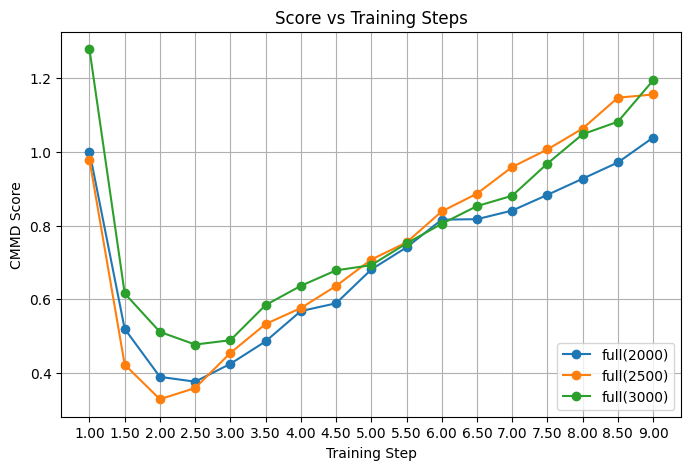

[[1.0006427764892578,
  0.5201101303100586,
  0.39005279541015625,
  0.3770589828491211,
  0.4253387451171875,
  0.4862546920776367,
  0.5682706832885742,
  0.5893707275390625,
  0.6810426712036133,
  0.7408857345581055,
  0.8159875869750977,
  0.8172988891601562,
  0.8406639099121094,
  0.8832216262817383,
  0.926971435546875,
  0.9709596633911133,
  1.0384321212768555],
 [0.9782314300537109,
  0.4233121871948242,
  0.3294944763183594,
  0.3598928451538086,
  0.45478343963623047,
  0.5332231521606445,
  0.5764961242675781,
  0.6363391876220703,
  0.7078647613525391,
  0.7543563842773438,
  0.8382797241210938,
  0.8865594863891602,
  0.9588003158569336,
  1.0062456130981445,
  1.0628700256347656,
  1.1464357376098633,
  1.155257225036621],
 [1.2778043746948242,
  0.6161928176879883,
  0.5118846893310547,
  0.47767162322998047,
  0.48935413360595703,
  0.5846023559570312,
  0.6366968154907227,
  0.6786584854125977,
  0.6927251815795898,
  0.7517337799072266,
  0.8047819137573242,
  0.85

In [ ]:


gen_img_paths = [
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng/{}",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of moodeng/{}",
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(1.0, 9.0 + 0.5, 0.5).tolist()]
labels = ["full(2000)","full(2500)","full(3000)"]
# "full(2000)",
compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.39it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/2.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.34it/s]


data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{} | Step 2.00 - CMMD score: 0.7323026657104492
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{} | Step 8.50 - CMMD score: 0.8656978607177734
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.38it/s]


Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/9.00-dummy-50.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.32it/s]

data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{} | Step 9.00 - CMMD score: 0.855565071105957


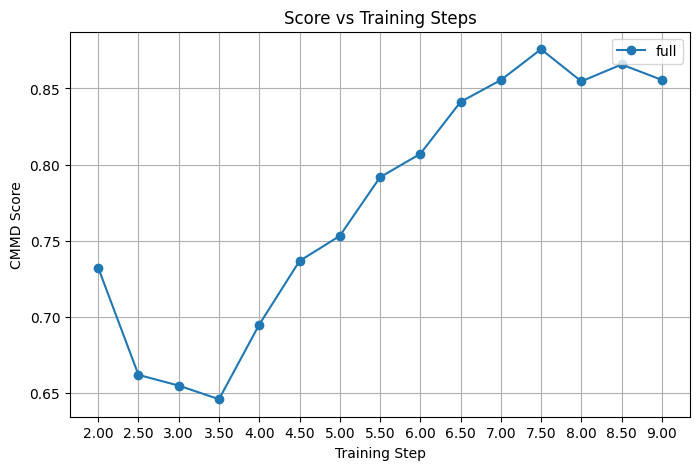

[[0.7323026657104492,
  0.6619691848754883,
  0.6549358367919922,
  0.6459951400756836,
  0.6949901580810547,
  0.7367134094238281,
  0.7531642913818359,
  0.7916688919067383,
  0.8070468902587891,
  0.8411407470703125,
  0.8554458618164062,
  0.8757114410400391,
  0.8546113967895508,
  0.8656978607177734,
  0.855565071105957]]

In [ ]:


gen_img_paths = [
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy/{}",
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
cfgs = [ f'{cfg:.2f}' for cfg in np.arange(2.0, 9.0 + 0.5, 0.5).tolist()]
labels = ["full"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, cfgs, labels, device=device, n_max_gen_img=50, method='cmmd')

compute KID between two folders
Found 50 images in the folder data_root/generated/general_concepts/A photo of a toy-dummy-50


KID A photo of a toy-dummy-50 : 100%|███████████████████████████████████████████| 2/2 [00:03<00:00,  1.78s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.88s/it]


data_root/generated/general_concepts/A photo of a toy | KID score: 0.09813588727678564
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy-dummy-50


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.06497011316167127
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:03<00:00,  1.85s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.69s/it]


data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.07338545129145428


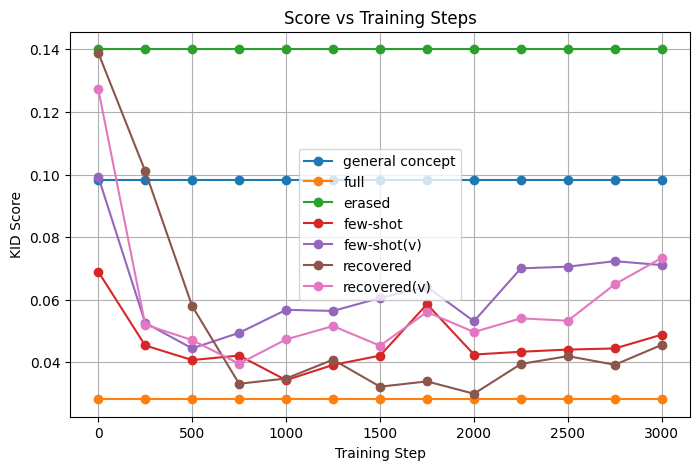

[[0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564,
  0.09813588727678564],
 [0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897,
  0.028230195591517897],
 [0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502,
  0.14003403974011502],
 [0.06900666617506367,
  0.045405861328125165,
  0.04074192203443888,
  0.0421783759566

In [ ]:


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='kid')

In [ ]:
# KID: test also w/o non-specail token


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

In [ ]:
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr1e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-3000/A photo of a crybaby art toy",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    # "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
ref_img_path = "data_root/data/real_data/crybaby/beforehq/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
# labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]
labels = ["general concept","full1","full2","full3","full4"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 23.59 GiB total capacity; 685.29 MiB already allocated; 10.44 MiB free; 696.00 MiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/beforehq/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.45it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.30it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.343152046203613
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/beforehq/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 1.623988151550293
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/beforehq/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.45it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.34it/s]

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 1.659989356994629


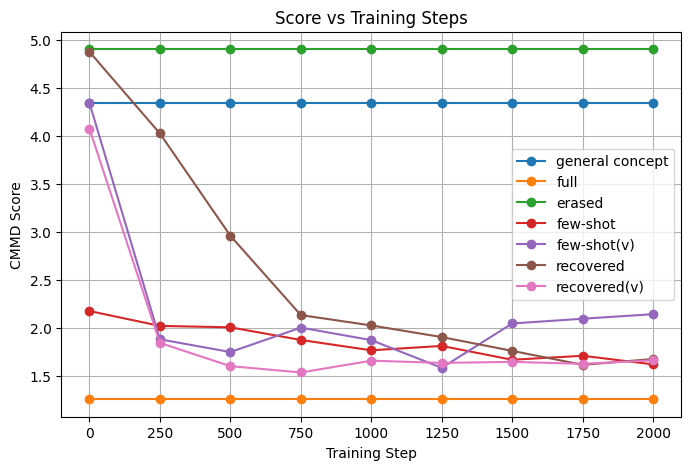

[[4.343152046203613,
  4.343152046203613,
  4.343152046203613,
  4.343152046203613,
  4.343152046203613,
  4.343152046203613,
  4.343152046203613,
  4.343152046203613,
  4.343152046203613],
 [1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742,
  1.2549161911010742],
 [4.903912544250488,
  4.903912544250488,
  4.903912544250488,
  4.903912544250488,
  4.903912544250488,
  4.903912544250488,
  4.903912544250488,
  4.903912544250488,
  4.903912544250488],
 [2.17437744140625,
  2.019166946411133,
  2.0046234130859375,
  1.8727779388427734,
  1.7648935317993164,
  1.8106698989868164,
  1.6660690307617188,
  1.7080307006835938,
  1.618027687072754],
 [4.343748092651367,
  1.8794536590576172,
  1.7467737197875977,
  2.001643180847168,
  1.8709897994995117,
  1.5823841094970703,
  2.0444393157958984,
  2.0940303802490234,
  2.1414756774902344],
 [4.876613616943359,
  4.0256

In [ ]:
# test also w/o non-specail token
# beforehq

gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/beforehq/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

compute KID between two folders
Found 50 images in the folder data_root/generated/general_concepts/A photo of a toy-dummy-50


KID A photo of a toy-dummy-50 : 100%|███████████████████████████████████████████| 2/2 [00:10<00:00,  5.46s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:12<00:00,  6.11s/it]


data_root/generated/general_concepts/A photo of a toy | KID score: 0.0981358557876275
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy-dummy-50


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - KID score: 0.056086762436224236
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:03<00:00,  1.92s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.71s/it]


data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - KID score: 0.04970848628826513


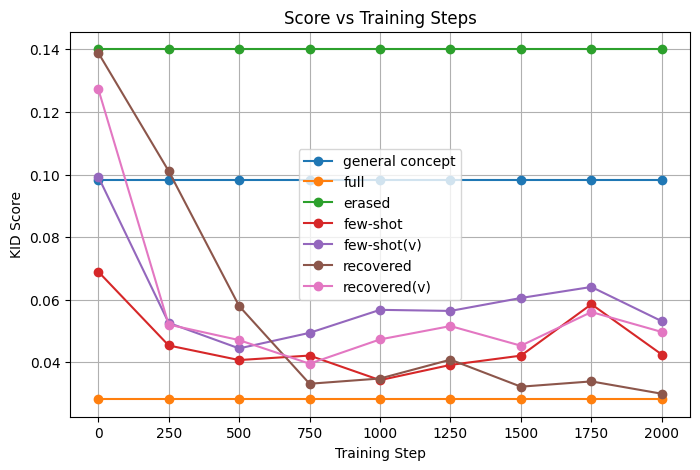

[[0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275],
 [0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968,
  0.028230201570471968],
 [0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712,
  0.14003402383609712],
 [0.06900665820312488,
  0.04540586726721954,
  0.040741906130421036,
  0.04217837790975773,
  0.03433035016741097,
  0.039191276347257296,
  0.04215206034757624,
  0.05857788588169614,
  0.042497714126275704],
 [0.09936333852838025,
  0.052619680604272794,
  0.04446396010044662,
  0.04943499418048443,
  0.056782055683992236,
  0.05643766206951515,
  0.060570593112244865,
 

In [ ]:
# KID: test also w/o non-specail token


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='kid')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.39it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.29it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.2465925216674805
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 1.007080078125
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.36it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 1.0260343551635742


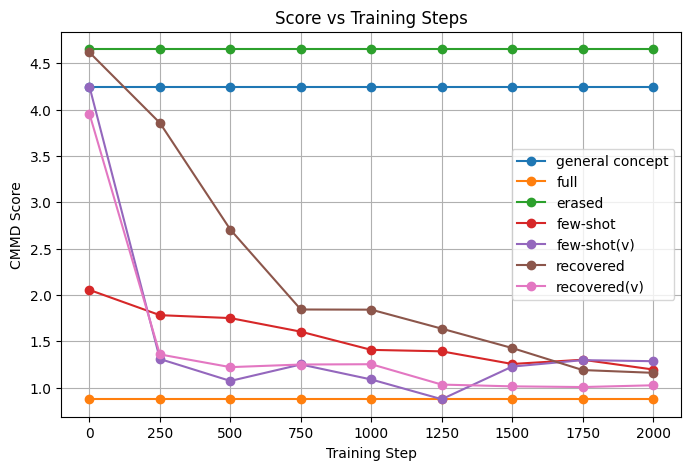

[[4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805],
 [0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391],
 [4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078],
 [2.054572105407715,
  1.7822980880737305,
  1.7508268356323242,
  1.604318618774414,
  1.4079809188842773,
  1.3922452926635742,
  1.2558698654174805,
  1.3015270233154297,
  1.196146011352539],
 [4.2476654052734375,
  1.309514045715332,
  1.0728836059570312,
  1.2505054473876953,
  1.0887384414672852,
  0.8758306503295898,
  1.227736473083496,
  1.2972354888916016,
  1.2857913970947266],
 [4.616260528564453

In [ ]:
# test also w/o non-specail token


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.26it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.757523536682129
Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 0.7464885711669922
Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.35it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 0.8829832077026367


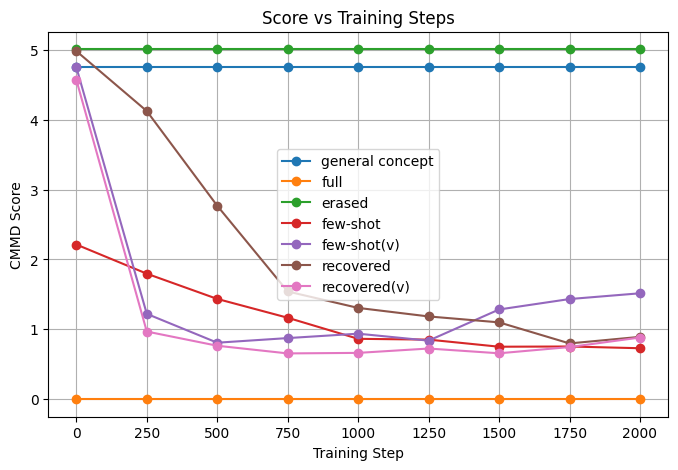

[[4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625],
 [2.213716506958008,
  1.7964839935302734,
  1.435399055480957,
  1.1658668518066406,
  0.8643865585327148,
  0.8530616760253906,
  0.7513761520385742,
  0.7544755935668945,
  0.729680061340332],
 [4.750967025756836,
  1.2216567993164062,
  0.8088350296020508,
  0.8748769760131836,
  0.9379386901855469,
  0.8382797241210938,
  1.2842416763305664,
  1.4334917068481445,
  1.5159845352172852],
 [4.98199462890625,
  4.123687744140625,
  2.7685165405273438,
  1.5418529510498047,
  1.3066530227661133,
  1.184701919555664,
  1.0999441146850586,
  0.7984638214111328,
  0.89

In [ ]:
# test also w/o non-specail token


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a crybaby art toy",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","few-shot(v)", "recovered","recovered(v)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.43it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.2465925216674805
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - CMMD score: 1.0943412780761719
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.44it/s]


data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - CMMD score: 1.186370849609375


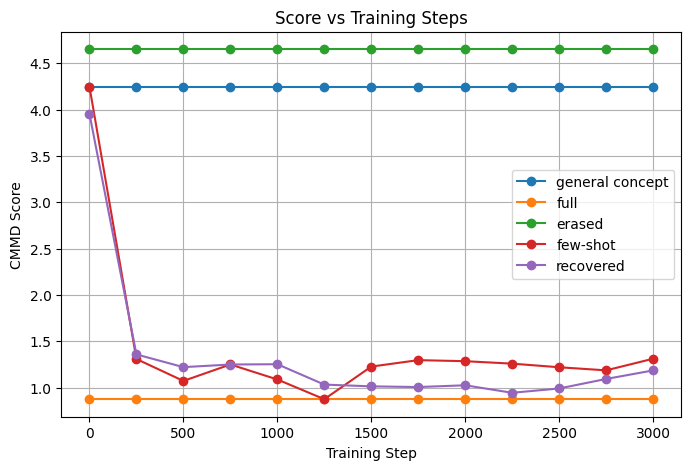

[[4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805],
 [0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391],
 [4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078],
 [4.2476654052734375,
  1.309514045715332,
  1.0728836059570312,
  1.2505054473876953,
  1.0887384414672852,
  0.8758306503295898,
  1.227736473083496,


In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.44it/s]


Calculating embeddings for 1000 images from data_root/generated/general_concepts/A photo of a toy.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [01:11<00:00,  1.40it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.236936569213867
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - CMMD score: 1.126408576965332
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.44it/s]


Calculating embeddings for 1000 images from data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [01:10<00:00,  1.42it/s]

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - CMMD score: 1.1281967163085938


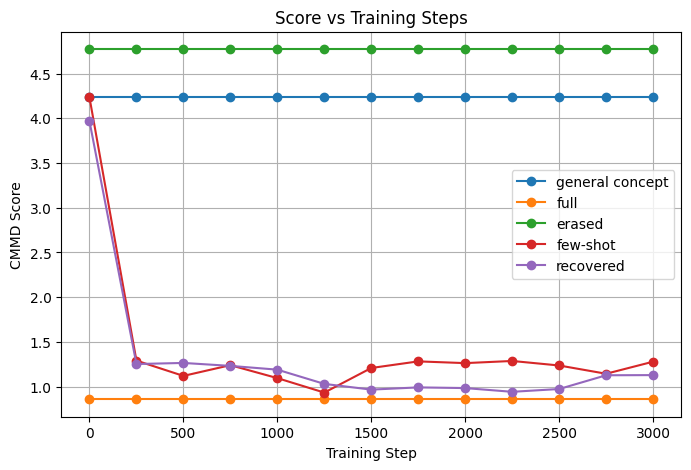

[[4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867],
 [0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266],
 [4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773],
 [4.233717918395996,
  1.290440559387207,
  1.1192560195922852,
  1.2392997741699219,
  1.0945796966552734,
  0.9326934814453125,
  1.2077093124389648,
  1.281619071

In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=None, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.36it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.27it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.2465925216674805
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 1.2392997741699219
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.12it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.11it/s]

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 1.1453628540039062


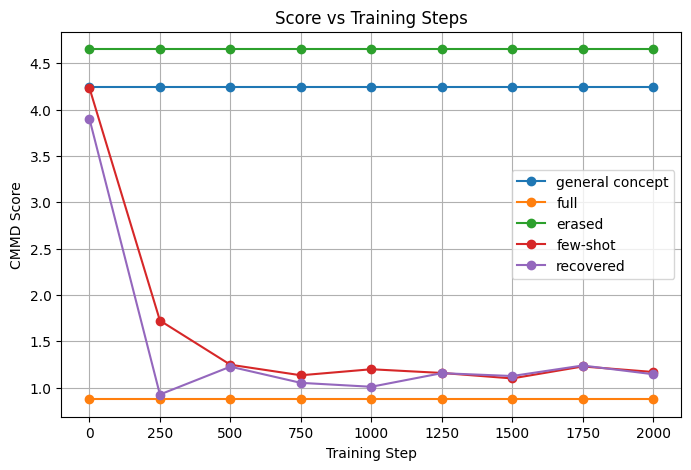

[[4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805,
  4.2465925216674805],
 [0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391,
  0.8757114410400391],
 [4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078,
  4.650592803955078],
 [4.2324066162109375,
  1.7242431640625,
  1.2476444244384766,
  1.134037971496582,
  1.198887825012207,
  1.159071922302246,
  1.0999441146850586,
  1.2290477752685547,
  1.1695623397827148],
 [3.8988590240478516,
  0.9266138076782227,
  1.2270212173461914,
  1.052260398864746,
  1.0099411010742188,
  1.1566877365112305,
  1.125931739807129,
  1.2392997741699219,
  1.1453628540039062]]

In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.38it/s]


Calculating embeddings for 1000 images from data_root/generated/general_concepts/A photo of a toy.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [00:43<00:00,  2.27it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.236936569213867
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


...

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 1.2621879577636719
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.41it/s]


Calculating embeddings for 1000 images from data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [01:25<00:00,  1.17it/s]

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 1.1790990829467773


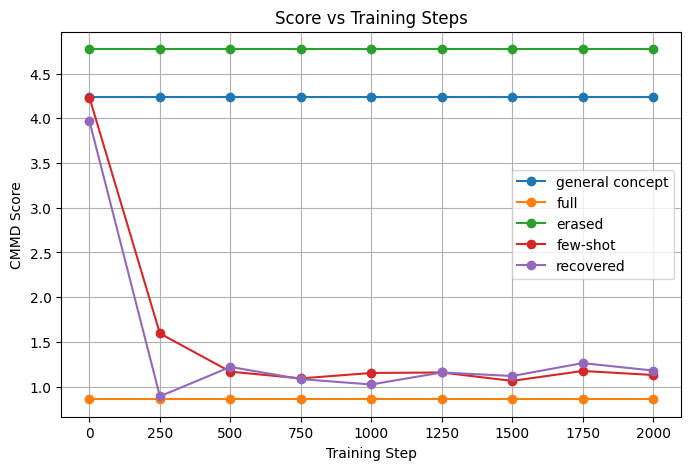

[[4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867,
  4.236936569213867],
 [0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266,
  0.8585453033447266],
 [4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773,
  4.771947860717773],
 [4.230976104736328,
  1.5935897827148438,
  1.1665821075439453,
  1.091599464416504,
  1.1519193649291992,
  1.1576414108276367,
  1.0634660720825195,
  1.1744499206542969,
  1.1295080184936523],
 [3.967165946960449,
  0.8908510208129883,
  1.2195110321044922,
  1.0832548141479492,
  1.023411750793457,
  1.1576414108276367,
  1.1180639266967773,
  1.2621879577636719,
  1.1790990829467773]]

In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=None, method='cmmd')

/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-crop.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.48s/it]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.38it/s]


...

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 1.916646957397461
Calculating embeddings for 50 images from data_root/data/real_data/crybaby/crybaby-crop.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.44it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.36it/s]

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 1.9044876098632812


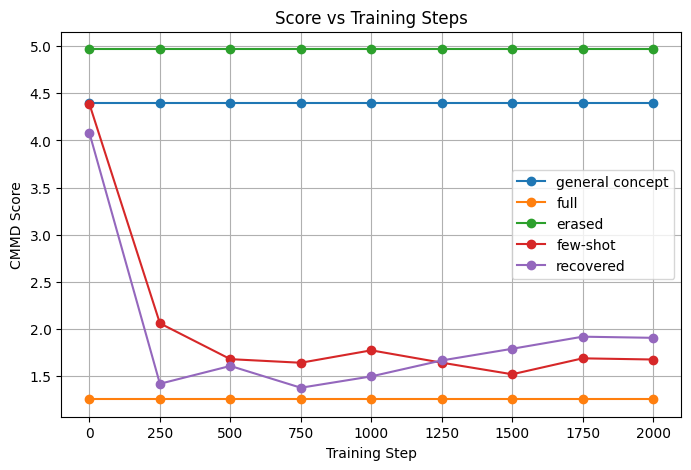

[[4.398822784423828,
  4.398822784423828,
  4.398822784423828,
  4.398822784423828,
  4.398822784423828,
  4.398822784423828,
  4.398822784423828,
  4.398822784423828,
  4.398822784423828],
 [1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094,
  1.2526512145996094],
 [4.968523979187012,
  4.968523979187012,
  4.968523979187012,
  4.968523979187012,
  4.968523979187012,
  4.968523979187012,
  4.968523979187012,
  4.968523979187012,
  4.968523979187012],
 [4.385232925415039,
  2.0585060119628906,
  1.6779899597167969,
  1.6398429870605469,
  1.7718076705932617,
  1.6406774520874023,
  1.5175342559814453,
  1.686692237854004,
  1.6742944717407227],
 [4.077553749084473,
  1.4166831970214844,
  1.605987548828125,
  1.3746023178100586,
  1.4950037002563477,
  1.664280891418457,
  1.7882585525512695,
  1.916646957397461,
  1.9044876098632812]]

In [ ]:
# test on raw


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-crop"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a toy-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.40it/s]


data_root/generated/general_concepts/A photo of a toy | CMMD score: 4.757523536682129
Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy.


...

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 1.2093782424926758
Calculating embeddings for 50 images from data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.41it/s]

data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 1.2007951736450195


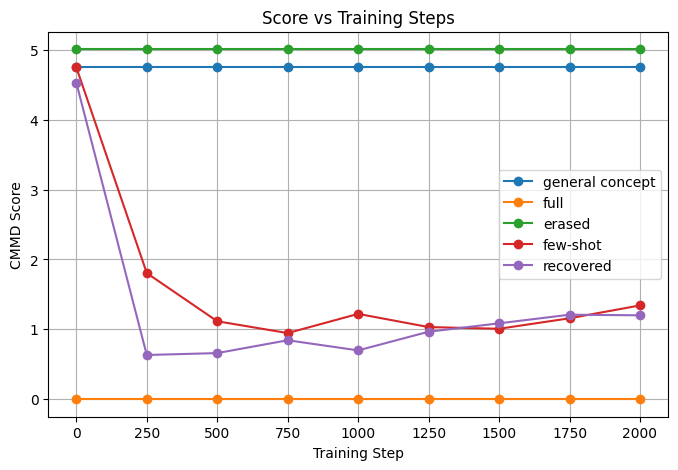

[[4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129,
  4.757523536682129],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625,
  5.008697509765625],
 [4.748702049255371,
  1.804947853088379,
  1.115560531616211,
  0.9466409683227539,
  1.2211799621582031,
  1.032710075378418,
  1.008152961730957,
  1.1583566665649414,
  1.342177391052246],
 [4.528164863586426,
  0.6328821182250977,
  0.6601810455322266,
  0.8438825607299805,
  0.6989240646362305,
  0.9659528732299805,
  1.086115837097168,
  1.2093782424926758,
  1.2007951736450195]]

In [ ]:
# test on full


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.38it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.34it/s]


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 2.5807619094848633
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 3.1501054763793945
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.37it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.28it/s]

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 3.0344724655151367


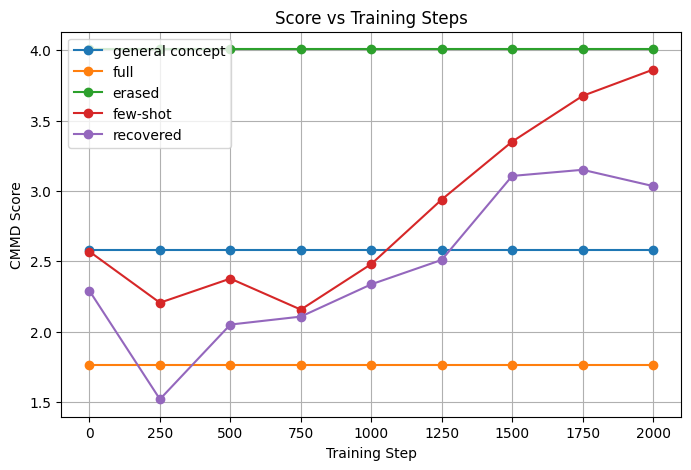

[[2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633],
 [1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484],
 [4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004],
 [2.56955623626709,
  2.20644474029541,
  2.377748489379883,
  2.15756893157959,
  2.4809837341308594,
  2.9391050338745117,
  3.3502578735351562,
  3.6749839782714844,
  3.8611888885498047],
 [2.2908449172973633,
  1.521468162536621,
  2.0514726638793945,
  2.107977867126465,
  2.337217330932617,
  2.510547637939453,
  3.1065940856933594,
  3.1501054763793945,
  3.0344724655151367]]

In [ ]:
# lora 4
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/old/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.00it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]
Error during conversion: ChunkedEncodingError(ProtocolError('Response ended prematurely'))


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 1.7801523208618164
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 2.2701025009155273
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.30it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.28it/s]

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 2.1789073944091797


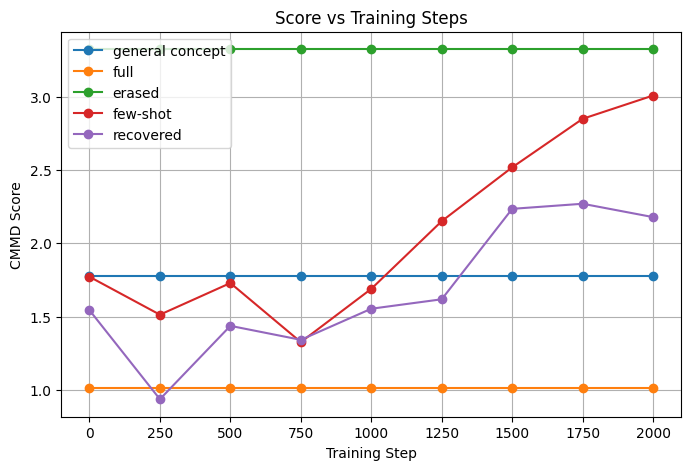

[[1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164],
 [1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898],
 [3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492],
 [1.771688461303711,
  1.5126466751098633,
  1.7287731170654297,
  1.3256072998046875,
  1.6890764236450195,
  2.1512508392333984,
  2.5186538696289062,
  2.850055694580078,
  3.009200096130371],
 [1.5435218811035156,
  0.9355545043945312,
  1.436471939086914,
  1.341104507446289,
  1.5534162521362305,
  1.6179084777832031,
  2.23541259765625,
  2.2701025009155273,
  2.1789073944091797]]

In [ ]:
# lora 4
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.37it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.41it/s]


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 1.7801523208618164
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - CMMD score: 1.8112659454345703
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.39it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.38it/s]

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - CMMD score: 2.116560935974121


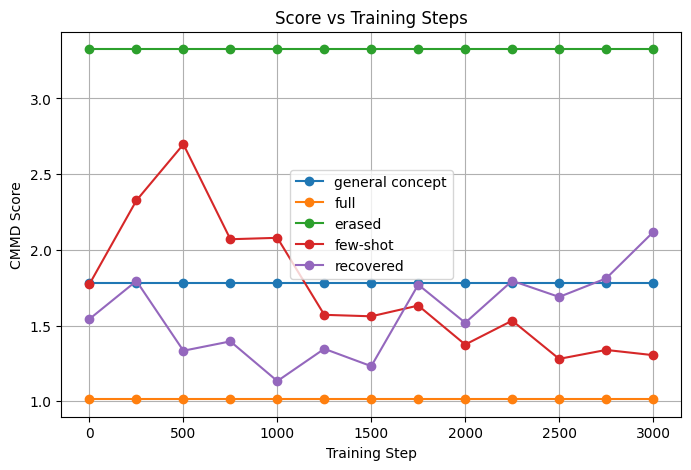

[[1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164],
 [1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898],
 [3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492],
 [1.7735958099365234,
  2.3262500762939453,
  2.697110176086426,
  2.0700693130493164,
  2.0793676376342773,
  1.5707015991210938,
  1.5609264373779297,

In [ ]:
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.39it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]
Error during conversion: ChunkedEncodingError(ProtocolError('Response ended prematurely'))


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 2.5807619094848633
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - CMMD score: 2.5238990783691406
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.37it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.26it/s]

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - CMMD score: 2.894878387451172


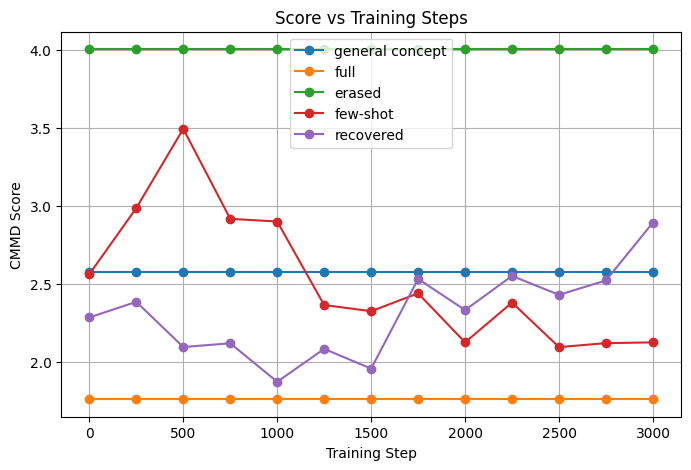

[[2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633],
 [1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484],
 [4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004],
 [2.5637149810791016,
  2.987384796142578,
  3.495931625366211,
  2.9186010360717773,
  2.901434898376465,
  2.3660659790039062,
  2.326488494873047,
  

In [ ]:
# test on sd data also with sd_model
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    
]
ref_img_path = "data_root/data/real_data/moodeng/old/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.05it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.34it/s]


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 2.5807619094848633
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3sd-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 2.0761489868164062
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/old/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.36it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3sd-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.27it/s]

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3sd-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 2.143263816833496


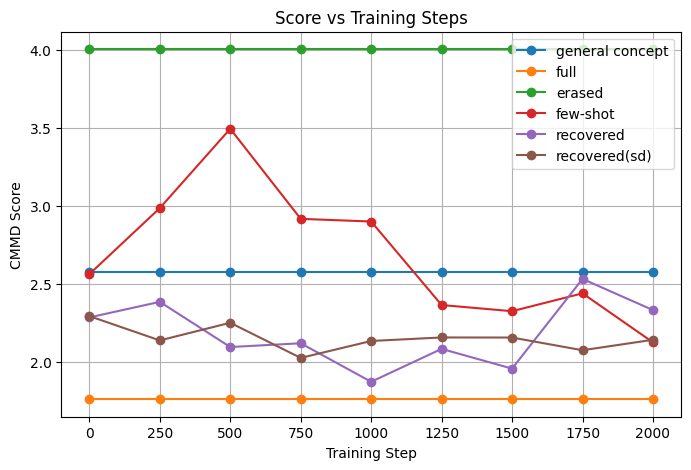

[[2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633,
  2.5807619094848633],
 [1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484,
  1.7621517181396484],
 [4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004,
  4.006028175354004],
 [2.5637149810791016,
  2.987384796142578,
  3.495931625366211,
  2.9186010360717773,
  2.901434898376465,
  2.3660659790039062,
  2.326488494873047,
  2.4410486221313477,
  2.1266937255859375],
 [2.286553382873535,
  2.38645076751709,
  2.0967721939086914,
  2.120852470397949,
  1.8739700317382812,
  2.0848512649536133,
  1.9583702087402344,
  2.5331974029541016,
  2.3336410522460938],
 [2.2950172424316406,


In [ ]:
# test on sd data also with sd_model
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3sd-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    
]
ref_img_path = "data_root/data/real_data/moodeng/old/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered","recovered(sd)"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.39it/s]


Calculating embeddings for 1000 images from data_root/generated/general_concepts/A photo of a hippo.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [01:22<00:00,  1.21it/s]


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 1.7944574356079102
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - CMMD score: 1.749873161315918
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.10it/s]


Calculating embeddings for 1000 images from data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [01:30<00:00,  1.11it/s]

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - CMMD score: 1.9369125366210938


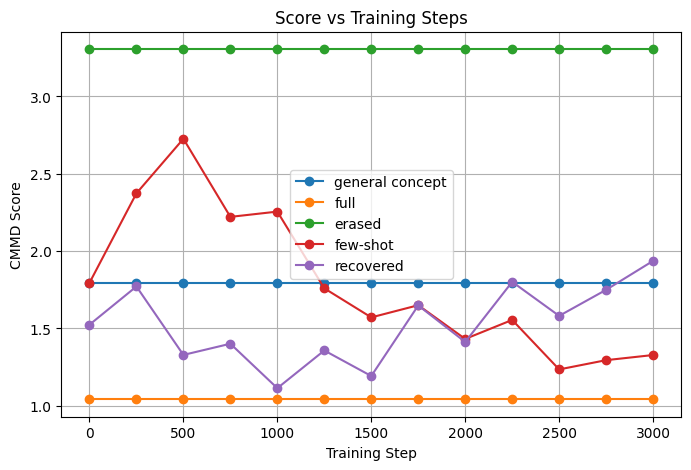

[[1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102,
  1.7944574356079102],
 [1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836,
  1.0427236557006836],
 [3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594,
  3.3049583435058594],
 [1.794576644897461,
  2.3735761642456055,
  2.7260780334472656,
  2.221345901489258,
  2.2554397583007812,
  1.7595291137695312,
  1.57165

In [ ]:
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=None, method='cmmd')

In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=None, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.85it/s]


Calculating embeddings for 50 images from data_root/generated/general_concepts/A photo of a hippo-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.33it/s]


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 1.7801523208618164
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


...

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - CMMD score: 2.2701025009155273
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.28it/s]


Calculating embeddings for 50 images from data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.25it/s]

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - CMMD score: 2.1789073944091797


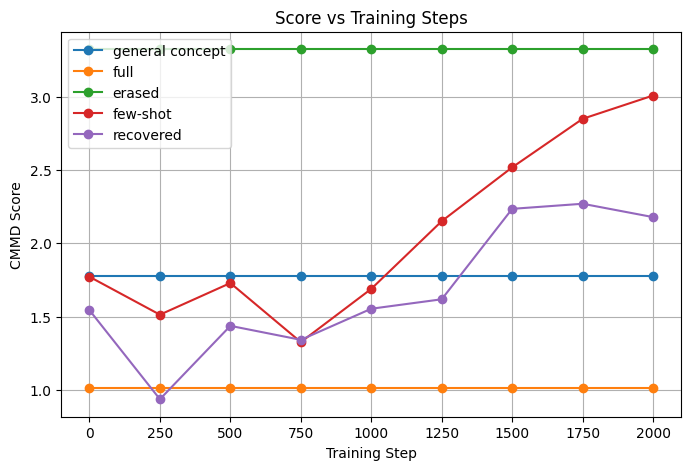

[[1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164,
  1.7801523208618164],
 [1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898,
  1.0131597518920898],
 [3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492,
  3.325223922729492],
 [1.771688461303711,
  1.5126466751098633,
  1.7287731170654297,
  1.3256072998046875,
  1.6890764236450195,
  2.1512508392333984,
  2.5186538696289062,
  2.850055694580078,
  3.009200096130371],
 [1.5435218811035156,
  0.9355545043945312,
  1.436471939086914,
  1.341104507446289,
  1.5534162521362305,
  1.6179084777832031,
  2.23541259765625,
  2.2701025009155273,
  2.1789073944091797]]

In [ ]:
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=50, method='cmmd')

In [ ]:
gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_distribution_score_multiexp(gen_img_paths, ref_img_path, steps, labels, device=device, n_max_gen_img=None, method='cmmd')

Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.29it/s]


Calculating embeddings for 1000 images from data_root/generated/general_concepts/A photo of a hippo.


100%|███████████████████████████████████████████████████████████████████████| 100/100 [00:49<00:00,  2.00it/s]


data_root/generated/general_concepts/A photo of a hippo | CMMD score: 1.7944574356079102
Calculating embeddings for 50 images from data_root/data/real_data/moodeng/moodeng-50.


100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.27it/s]


Calculating embeddings for 1000 images from data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng.


 51%|████████████████████████████████████▋                                   | 51/100 [00:26<00:25,  1.95it/s]


KeyboardInterrupt: 

In [ ]:
# python metrics/cmmd_pytorch/main.py  "data_root/data/real_data/moodeng/moodeng-50" "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-0/A photo of a v1" --batch_size=32 --max_count=50


score = compute_cmmd(ref_dir="data_root/data/real_data/moodeng/moodeng-50", eval_dir="data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-0/A photo of a v1", batch_size=50, max_count=20)

Calculating embeddings for 20 images from data_root/data/real_data/moodeng/moodeng-50.


1it [00:01,  1.42s/it]


Calculating embeddings for 20 images from data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-0/A photo of a v1.


1it [00:01,  1.31s/it]


In [ ]:
score.item()

1.7046928405761719